In [39]:
import kagglehub
import shutil
import os

# 1. Download the latest version to the default cache
cache_path = kagglehub.dataset_download("camnugent/california-housing-prices")
print("Downloaded to cache at:", cache_path)

# 2. Define your specific destination folder
target_folder = "."

# 3. Copy the contents from the cache to your target folder
shutil.copytree(cache_path, target_folder, dirs_exist_ok=True)

print(f"Dataset is now ready directly in: {target_folder}") 

Downloaded to cache at: C:\Users\Annie\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1
Dataset is now ready directly in: .


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
data = pd.read_csv("housing.csv")

In [42]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [43]:
# light EDA before splitting, deep EDA will be done on the training set only to avoid data leakage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [44]:
data.dropna(inplace=True) # inplace=True to modify the original DataFrame
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [45]:
# splitting the dataset into features and target variable
from sklearn.model_selection import train_test_split

X = data.drop(["median_house_value"], axis=1) # axis=1 means drop column, axis=0 means drop row
y = data["median_house_value"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [47]:
# join the training features and target variable for EDA
train_data = X_train.join(y_train)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

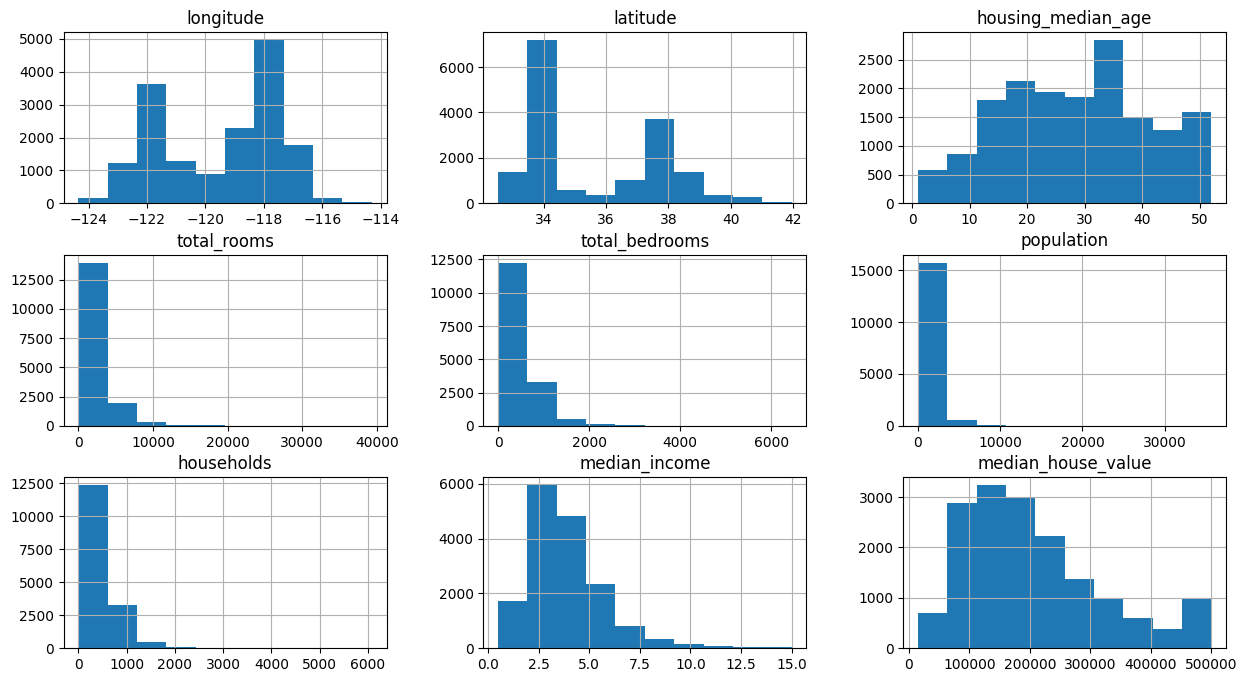

In [48]:
train_data.hist(figsize=(15, 8))

In [49]:
# log transformation of skewed features to make them more normally distributed
col = ['total_rooms', 'total_bedrooms', 'population', 'households']
train_data[col] = train_data[col].apply(lambda x: np.log1p(x)) # log1p is used to avoid log(0) which is undefined
# train_data[col] = train_data[col].apply(lambda x: np.log(x+1))

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

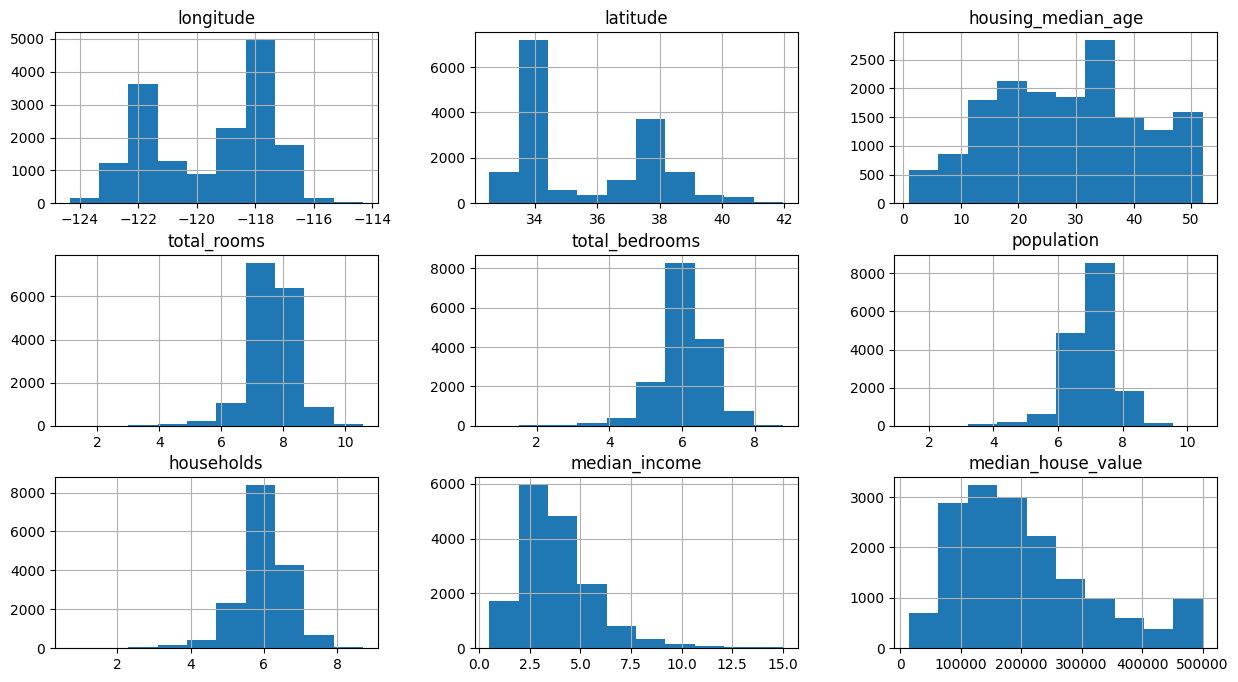

In [50]:
train_data.hist(figsize=(15, 8))

In [51]:
train_data.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924641,-0.115105,0.023927,0.054619,0.103018,0.048402,-0.013082,-0.042526
latitude,-0.924641,1.000000,0.016029,-0.027565,-0.062910,-0.132108,-0.082316,-0.081778,-0.146616
housing_median_age,-0.115105,0.016029,1.000000,-0.313793,-0.273846,-0.243736,-0.241519,-0.113630,0.107148
total_rooms,0.023927,-0.027565,-0.313793,1.000000,0.945365,0.863811,0.930346,0.203770,0.159820
total_bedrooms,0.054619,-0.062910,-0.273846,0.945365,1.000000,0.897273,0.973868,-0.028699,0.053107
population,0.103018,-0.132108,-0.243736,0.863811,0.897273,1.000000,0.933076,-0.010560,-0.023380
households,0.048402,-0.082316,-0.241519,0.930346,0.973868,0.933076,1.000000,0.000445,0.072534
median_income,-0.013082,-0.081778,-0.113630,0.203770,-0.028699,-0.010560,0.000445,1.000000,0.691863
median_house_value,-0.042526,-0.146616,0.107148,0.159820,0.053107,-0.023380,0.072534,0.691863,1.000000


<Axes: >

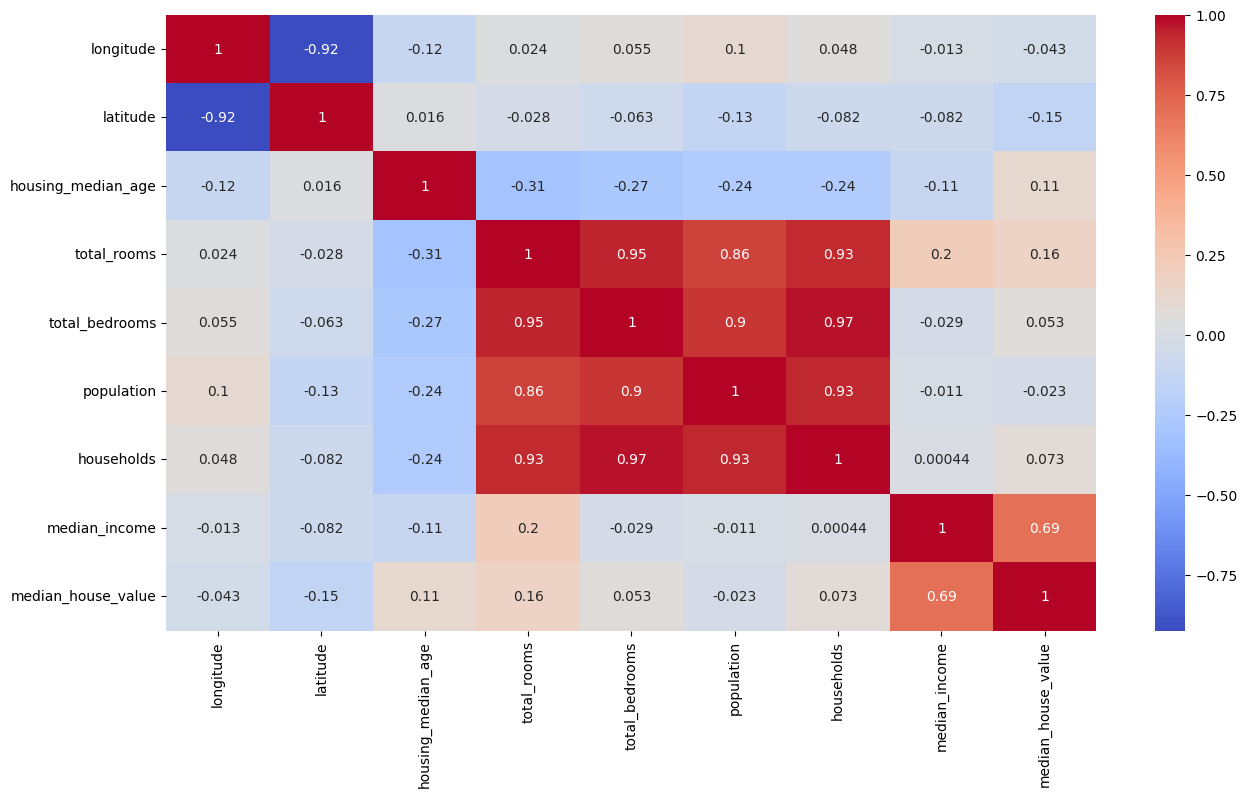

In [52]:
# plt is used to set the figure size, while sns is used to create the heatmap.
plt.figure(figsize=(15, 8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="coolwarm") # annot=True to show correlation values on the heatmap

In [53]:
# check the distribution of the textual feature 'ocean_proximity' in the training set
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7254
INLAND        5185
NEAR OCEAN    2090
NEAR BAY      1815
ISLAND           2
Name: count, dtype: int64

In [56]:
# create dummy variables for the categorical feature 'ocean_proximity'
train_data.join(pd.get_dummies(train_data['ocean_proximity']), dtype=int).head()

TypeError: DataFrame.join() got an unexpected keyword argument 'dtype'

In [ ]:
train_data.drop("ocean_proximity", axis=1).head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
2518,-122.13,39.74,20.0,1401.0,280.0,668.0,250.0,2.2569,94300.0
11511,-118.11,33.73,32.0,1258.0,333.0,645.0,334.0,5.0476,500001.0
8557,-118.40,33.93,35.0,2217.0,447.0,1000.0,450.0,4.7319,376100.0
5778,-118.26,34.15,14.0,2981.0,894.0,1941.0,863.0,3.0000,178600.0
1161,-121.54,39.51,33.0,3585.0,757.0,1887.0,765.0,2.5020,62100.0
...,...,...,...,...,...,...,...,...,...
1106,-121.60,39.80,10.0,1742.0,307.0,721.0,312.0,2.4537,117900.0
19081,-122.48,38.31,29.0,2375.0,560.0,1124.0,502.0,2.3276,166200.0
11915,-117.40,33.95,46.0,2189.0,423.0,866.0,389.0,3.1384,111500.0
6709,-118.15,34.14,52.0,403.0,117.0,361.0,105.0,1.6250,187500.0
